In [32]:
from pathlib import Path
from collections import namedtuple
import pprint
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import StandardScaler
import scipy.io

from tqdm.notebook import tqdm

# Setup

In [137]:
project_root_path = ! git rev-parse --show-toplevel
project_root_path = Path(project_root_path[0])

RNG = np.random.default_rng()

CONFIG = namedtuple('Config', 'project_root_path, data_path, sparsenet_path, dataset_name, dataset_size')(
    project_root_path=project_root_path,
    data_path=project_root_path / 'data',
    sparsenet_path=project_root_path / 'data' / 'sparsenet',
    dataset_name='CIFAR10',
    dataset_size=10_000
)

pprint.pprint(CONFIG._asdict())

{'data_path': PosixPath('/home/misha/dev/mine/neurovision/data'),
 'dataset_name': 'CIFAR10',
 'dataset_size': 10000,
 'project_root_path': PosixPath('/home/misha/dev/mine/neurovision'),
 'sparsenet_path': PosixPath('/home/misha/dev/mine/neurovision/data/sparsenet')}


# Dataset

In [138]:
ImagePatch = namedtuple('ImagePatch', 'patch image_ind i_off j_off')

def extract_image_patch(images, patch_size, image_ind=None, image_stds=None, rng=None):
    blind_area = 4
    trials = 1000
    rng = RNG if rng is None else rng
    image_ind = rng.choice(len(images)) if image_ind is None else image_ind
    image = images[image_ind]

    with_std = not image_stds is None
    
    if with_std:
        image_std_thres = image_stds[image_ind] * .1

    for _ in range(trials):
        i_off = blind_area + rng.choice(image.shape[0] - 2 * blind_area - patch_size)
        j_off = blind_area + rng.choice(image.shape[1] - 2 * blind_area - patch_size)
        patch = image[i_off:i_off + patch_size, j_off:j_off + patch_size]
        
        if with_std:
            patch_std = patch.ravel().std()
    
            if patch_std < image_std_thres:
                continue
        
        break
    else:
        assert False, f'Failed to extract image patch within {trials} trials'
    
    return ImagePatch(patch, image_ind, i_off, j_off)

In [139]:
match CONFIG.dataset_name:
    case 'CIFAR10':
        (IMAGES, y_train), (X_test, y_test) = cifar10.load_data()
        IMAGES = IMAGES[:CONFIG.dataset_size]
        IMAGE_SHAPE = IMAGES.shape[1:3]
        IMAGES = IMAGES[...,1] # get green channel
        IMAGES = IMAGES.reshape(*IMAGES.shape, 1)
    case 'sparsenet':
        mat = scipy.io.loadmat(CONFIG.sparsenet_path / 'IMAGES_RAW.mat')
        raw_images = mat['IMAGESr']
        raw_images = np.moveaxis(raw_images, [2], [0])
        IMAGES = []
        IMAGE_SHAPE = (12, 12)
        
        for i in tqdm(range(CONFIG.dataset_size)):
            patch = extract_image_patch(raw_images, IMAGE_SHAPE[0]).patch
            IMAGES.append(patch.ravel())
        
        IMAGES = np.array(IMAGES)
        IMAGES = IMAGES.reshape(len(IMAGES), *IMAGE_SHAPE, 1)
    case _:
        assert False, f'Unsupported dataset_name={CONFIG.dataset_name}'

print(f'Dataset "{CONFIG.dataset_name}" loaded, {len(IMAGES)} items')

Dataset "CIFAR10" loaded, 10000 items


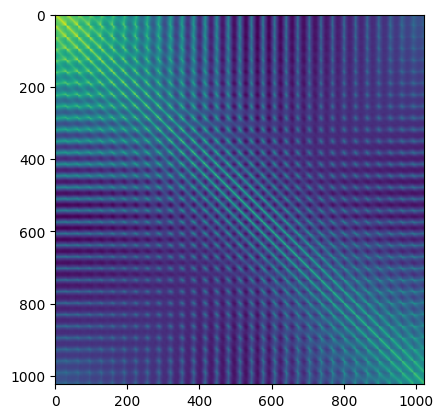

In [140]:
plt.imshow(np.cov(IMAGES.reshape(IMAGES.shape[0], -1), rowvar=False));

In [141]:
TEST_IMAGE_IND = RNG.choice(len(IMAGES))

# Centering

In [142]:
zca_images = IMAGES.astype('float32').copy()
assert zca_images.base is None
print(zca_images.min(), zca_images.max())

zca_images = zca_images.reshape(len(zca_images), -1)
scaler = StandardScaler(with_std=False)
zca_images = scaler.fit_transform(zca_images)
Σ = np.cov(zca_images, rowvar=False)    

0.0 255.0


## Whitened Σ 

In [143]:
np.round(Σ[:8,:8], 2)

array([[5402.04, 5199.69, 5010.7 , 4856.92, 4745.04, 4641.5 , 4545.04,
        4464.34],
       [5199.69, 5254.95, 5114.61, 4916.03, 4787.77, 4670.53, 4567.45,
        4481.9 ],
       [5010.7 , 5114.61, 5218.94, 5074.97, 4899.19, 4762.29, 4648.13,
        4556.26],
       [4856.92, 4916.03, 5074.97, 5182.97, 5053.07, 4865.13, 4728.14,
        4620.63],
       [4745.04, 4787.77, 4899.19, 5053.07, 5156.52, 5016.02, 4825.2 ,
        4692.53],
       [4641.5 , 4670.53, 4762.29, 4865.13, 5016.02, 5117.95, 4977.97,
        4798.29],
       [4545.04, 4567.45, 4648.13, 4728.14, 4825.2 , 4977.97, 5077.54,
        4951.44],
       [4464.34, 4481.9 , 4556.26, 4620.63, 4692.53, 4798.29, 4951.44,
        5069.02]])

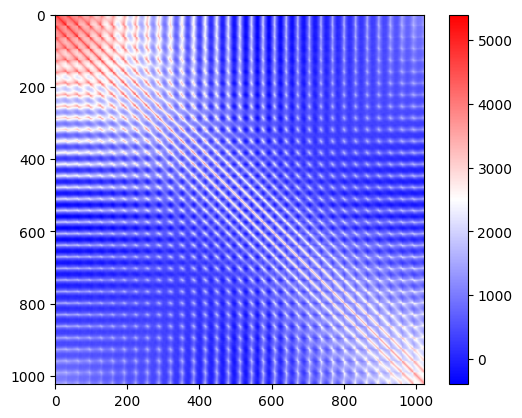

In [144]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Sample

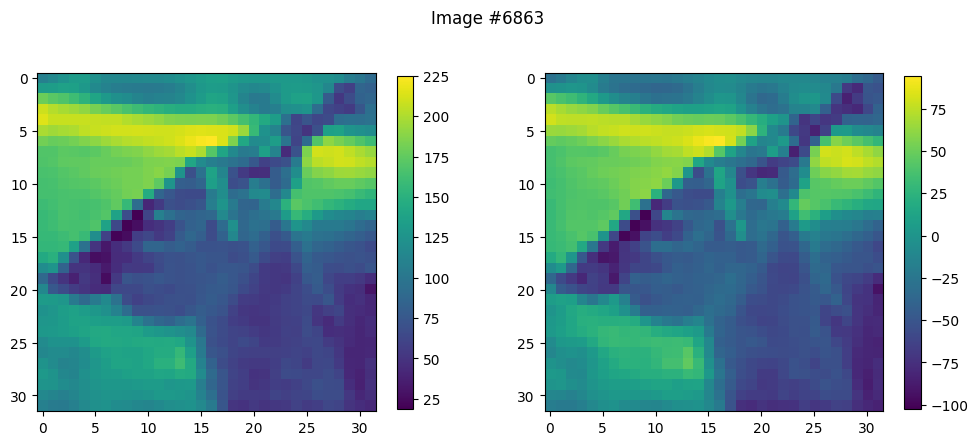

In [145]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

fig.suptitle(f'Image #{image_ind}')

im = ax1.imshow(IMAGES[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)
im = ax2.imshow(zca_images[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

# Standardization

In [146]:
zca_images = IMAGES.astype('float32').copy()
assert zca_images.base is None
print(zca_images.min(), zca_images.max())

zca_images = zca_images.reshape(len(zca_images), -1)
scaler = StandardScaler(with_std=True)
zca_images = scaler.fit_transform(zca_images)
Σ = np.cov(zca_images, rowvar=False)    

0.0 255.0


## Whitened Σ 

In [147]:
np.round(Σ[:8,:8], 2)

array([[1.  , 0.98, 0.94, 0.92, 0.9 , 0.88, 0.87, 0.85],
       [0.98, 1.  , 0.98, 0.94, 0.92, 0.9 , 0.88, 0.87],
       [0.94, 0.98, 1.  , 0.98, 0.94, 0.92, 0.9 , 0.89],
       [0.92, 0.94, 0.98, 1.  , 0.98, 0.94, 0.92, 0.9 ],
       [0.9 , 0.92, 0.94, 0.98, 1.  , 0.98, 0.94, 0.92],
       [0.88, 0.9 , 0.92, 0.94, 0.98, 1.  , 0.98, 0.94],
       [0.87, 0.88, 0.9 , 0.92, 0.94, 0.98, 1.  , 0.98],
       [0.85, 0.87, 0.89, 0.9 , 0.92, 0.94, 0.98, 1.  ]])

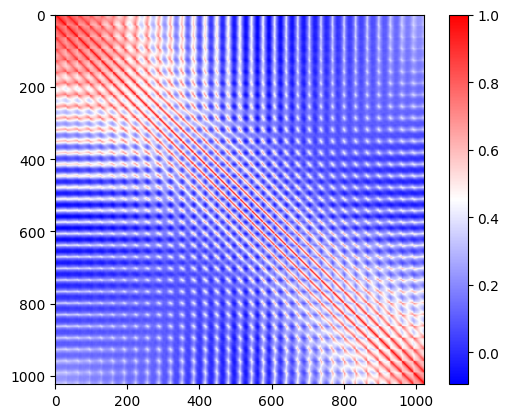

In [148]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Sample

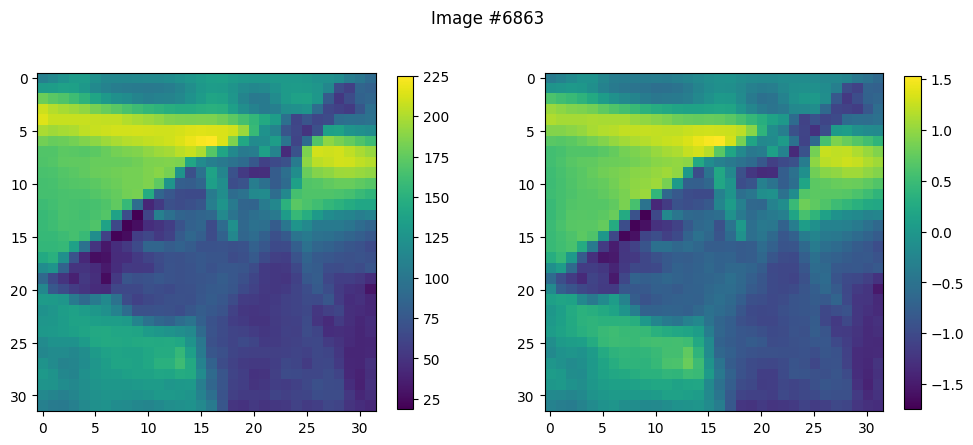

In [149]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

fig.suptitle(f'Image #{image_ind}')

im = ax1.imshow(IMAGES[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)
im = ax2.imshow(zca_images[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

# ZCA Whitening via Keras

In [150]:
zca_images = IMAGES.astype('float32').copy()
assert zca_images.base is None
print(zca_images.min(), zca_images.max())

datagen = ImageDataGenerator(featurewise_center=True, zca_whitening=True)
datagen.fit(zca_images)

for i in tqdm(range(len(zca_images))):
    zca_images[i] = datagen.standardize(zca_images[i])

Σ = np.cov(zca_images.reshape(zca_images.shape[0], -1), rowvar=False)    

0.0 255.0


  0%|          | 0/10000 [00:00<?, ?it/s]

## Whitened Σ 

In [151]:
np.round(Σ[:8,:8], 2)

array([[ 1.,  0., -0., -0., -0., -0., -0., -0.],
       [ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-0.,  0.,  1., -0., -0., -0., -0., -0.],
       [-0.,  0., -0.,  1., -0., -0., -0., -0.],
       [-0.,  0., -0., -0.,  1., -0., -0., -0.],
       [-0.,  0., -0., -0., -0.,  1., -0., -0.],
       [-0.,  0., -0., -0., -0., -0.,  1., -0.],
       [-0.,  0., -0., -0., -0., -0., -0.,  1.]])

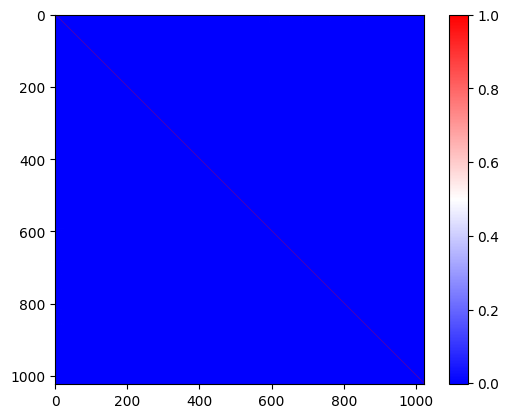

In [152]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Sample

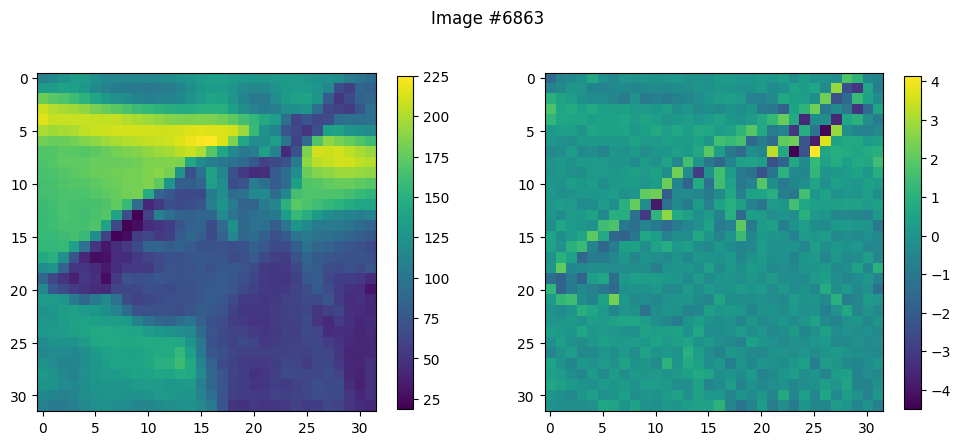

In [153]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

fig.suptitle(f'Image #{image_ind}')

im = ax1.imshow(IMAGES[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)
im = ax2.imshow(zca_images[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

# ZCA Whitening via Home-made: clamp [0,1]

In [154]:
zca_images = IMAGES.astype('float32').copy()
assert zca_images.base is None
print(zca_images.min(), zca_images.max())

zca_images = zca_images.reshape(len(zca_images), -1)
mins = zca_images.min(axis=0)
maxs = zca_images.max(axis=0)
zca_images = (zca_images - mins) / (maxs - mins)

zca_images = zca_images - zca_images.mean(axis=0)

Σ = np.cov(zca_images, rowvar=False)
u, s, _ = np.linalg.svd(Σ)
zca_images = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ zca_images.T).T

Σ = np.cov(zca_images, rowvar=False)    

0.0 255.0


## Whitened Σ 

In [155]:
np.round(Σ[:8,:8], 2)

array([[ 1.,  0., -0.,  0., -0.,  0., -0., -0.],
       [ 0.,  1.,  0., -0.,  0., -0.,  0., -0.],
       [-0.,  0.,  1.,  0., -0.,  0., -0.,  0.],
       [ 0., -0.,  0.,  1.,  0., -0.,  0., -0.],
       [-0.,  0., -0.,  0.,  1.,  0., -0.,  0.],
       [ 0., -0.,  0., -0.,  0.,  1.,  0., -0.],
       [-0.,  0., -0.,  0., -0.,  0.,  1.,  0.],
       [-0., -0.,  0., -0.,  0., -0.,  0.,  1.]])

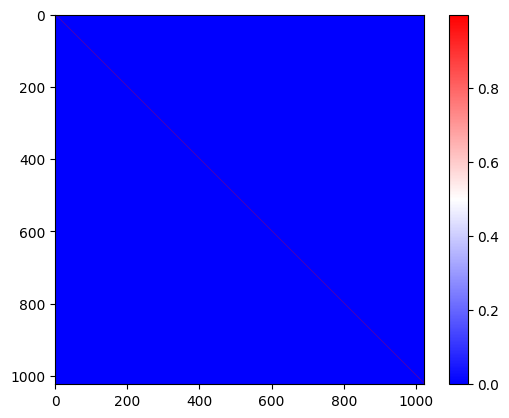

In [156]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Sample

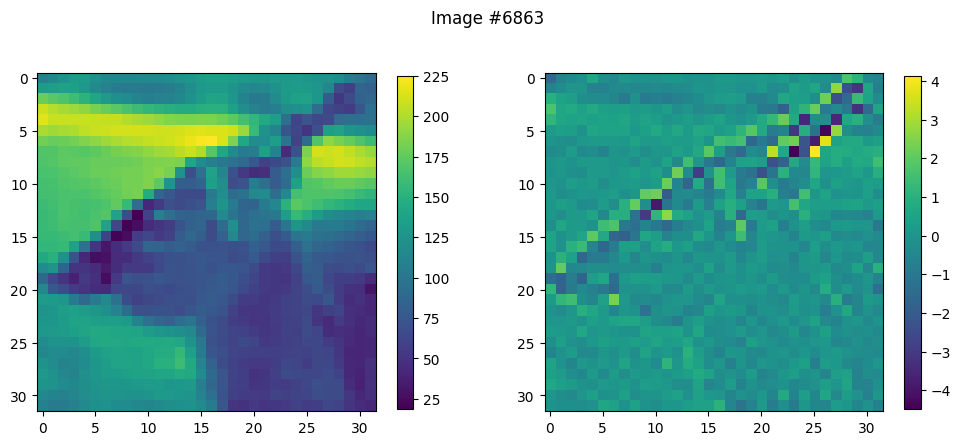

In [157]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

fig.suptitle(f'Image #{image_ind}')

im = ax1.imshow(IMAGES[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)
im = ax2.imshow(zca_images[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

# ZCA Whitening via Home-made: no clamp

In [158]:
zca_images = IMAGES.astype('float32').copy()
assert zca_images.base is None
print(zca_images.min(), zca_images.max())

zca_images = zca_images.reshape(len(zca_images), -1)
zca_images = zca_images - zca_images.mean(axis=0)

Σ = np.cov(zca_images, rowvar=False)
u, s, _ = np.linalg.svd(Σ)
zca_images = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ zca_images.T).T

Σ = np.cov(zca_images, rowvar=False)    

0.0 255.0


## Whitened Σ 

In [159]:
np.round(Σ[:8,:8], 2)

array([[ 1.,  0., -0.,  0., -0.,  0., -0., -0.],
       [ 0.,  1.,  0., -0.,  0., -0.,  0., -0.],
       [-0.,  0.,  1.,  0., -0.,  0., -0.,  0.],
       [ 0., -0.,  0.,  1.,  0., -0.,  0., -0.],
       [-0.,  0., -0.,  0.,  1.,  0., -0.,  0.],
       [ 0., -0.,  0., -0.,  0.,  1.,  0., -0.],
       [-0.,  0., -0.,  0., -0.,  0.,  1.,  0.],
       [-0., -0.,  0., -0.,  0., -0.,  0.,  1.]])

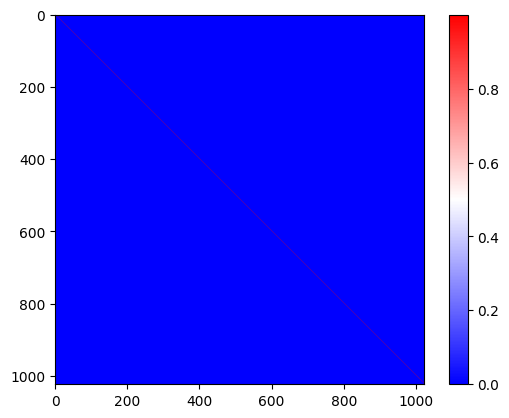

In [160]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Sample

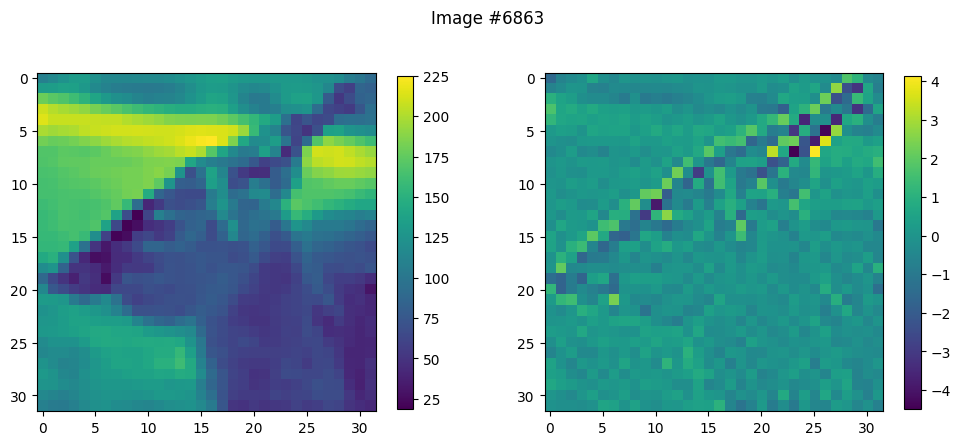

In [161]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

fig.suptitle(f'Image #{image_ind}')

im = ax1.imshow(IMAGES[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)
im = ax2.imshow(zca_images[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

# PCA Whitening

In [162]:
pca_images = IMAGES.astype('float32').copy()
assert pca_images.base is None
print(pca_images.min(), pca_images.max())

pca_images = pca_images.reshape(len(pca_images), -1)
pca_images = pca_images - pca_images.mean(axis=0)

Σ = np.cov(pca_images, rowvar=False)
eigvals, eigvecs = np.linalg.eig(Σ)
R, S = eigvecs, np.diag(np.sqrt(eigvals))
T = R @ S
T_inv = np.linalg.inv(T)
pca_images = (T_inv @ pca_images.T).T

Σ = np.cov(pca_images, rowvar=False)

0.0 255.0


## Whitened Σ 

In [163]:
np.round(Σ[:8,:8], 2)

array([[ 1., -0., -0.,  0.,  0., -0., -0.,  0.],
       [-0.,  1.,  0.,  0.,  0.,  0., -0., -0.],
       [-0.,  0.,  1.,  0., -0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1., -0.,  0.,  0., -0.],
       [ 0.,  0., -0., -0.,  1.,  0., -0.,  0.],
       [-0.,  0.,  0.,  0.,  0.,  1.,  0., -0.],
       [-0., -0.,  0.,  0., -0.,  0.,  1., -0.],
       [ 0., -0.,  0., -0.,  0., -0., -0.,  1.]])

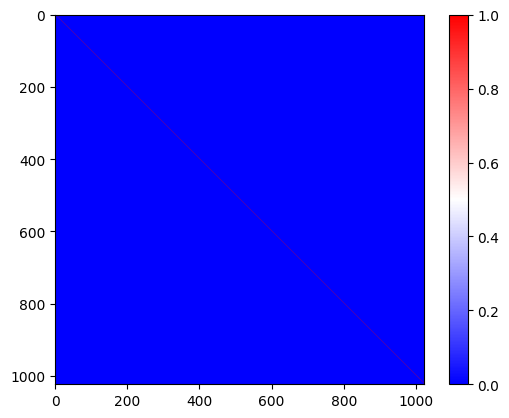

In [164]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Sample

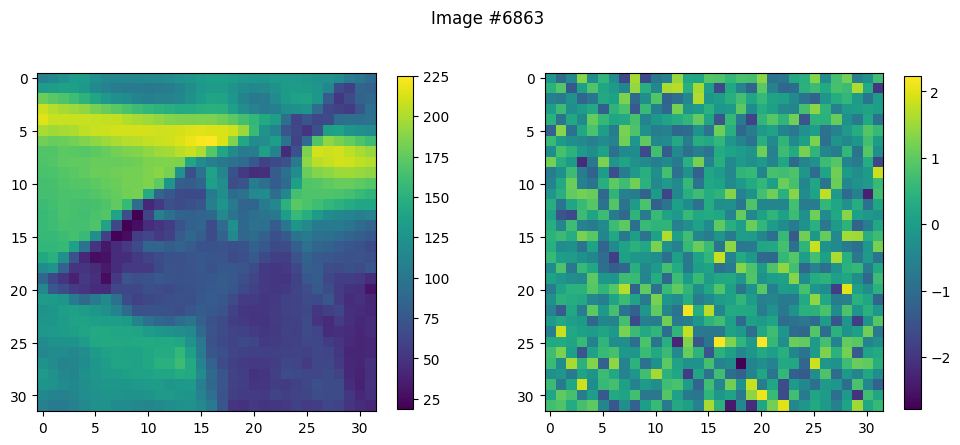

In [165]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

fig.suptitle(f'Image #{image_ind}')

im = ax1.imshow(IMAGES[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)
im = ax2.imshow(pca_images[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);